# Results Analysis

Comparing model performance across clean and spurious training conditions.

In [1]:
import json
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

with open("../summary.json") as f:
    data = json.load(f)

# data.pop('alexnet_pos0.1_neg0.5')
# data.pop('alexnet_pos0.5_neg0.1')

label_map = {
    "alexnet_clean": "Clean",
    "alexnet_pos0.5_neg0.3": "Spur pos=0.5 neg=0.3",
    "alexnet_pos0.3_neg0.5": "Spur pos=0.3 neg=0.5"
    # "alexnet_pos0.5_neg0.0": "Spur pos=0.5 neg=0.0",
    # "alexnet_pos0.0_neg0.5": "Spur pos=0.0 neg=0.5",
    # "alexnet_pos0.1_neg0.5": "Spur pos=0.1 neg=0.5",
    # "alexnet_pos0.5_neg0.1": "Spur pos=0.5 neg=0.1",
}

model_order = [
    "alexnet_clean",
    "alexnet_pos0.5_neg0.3",
    "alexnet_pos0.3_neg0.5",
]
models = [m for m in model_order if m in data]
labels = [label_map.get(m, m) for m in models]
metrics = ["accuracy", "precision", "recall", "f1", "auc", "loss"]

print("Loaded models:", labels)

Loaded models: ['Clean', 'Spur pos=0.5 neg=0.3', 'Spur pos=0.3 neg=0.5']


## All Metrics - Grouped Bar Chart

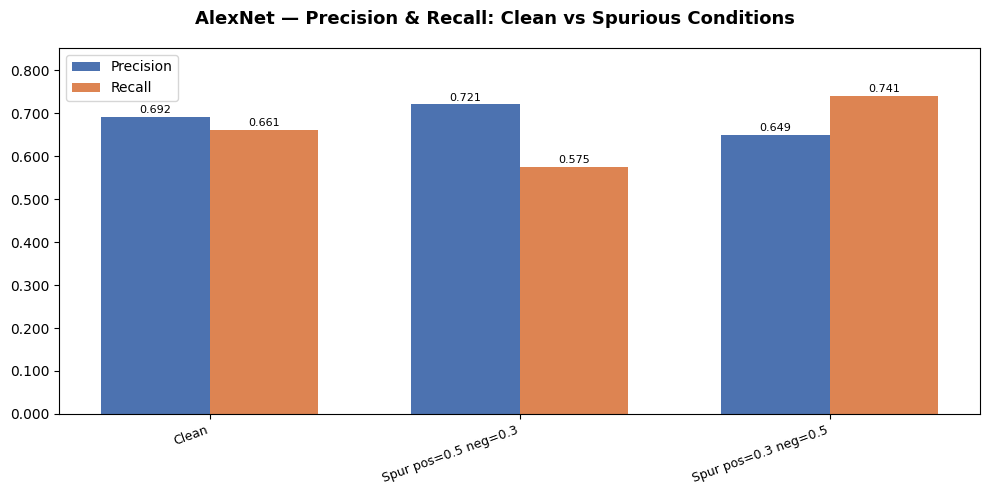

In [2]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(models))
bar_width = 0.35
precision_color = "#4C72B0"
recall_color = "#DD8452"

precision_vals = [data[m]["precision"] for m in models]
recall_vals = [data[m]["recall"] for m in models]

bars_p = ax.bar(x - bar_width / 2, precision_vals, width=bar_width, color=precision_color, label="Precision")
bars_r = ax.bar(x + bar_width / 2, recall_vals,    width=bar_width, color=recall_color,    label="Recall")

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
ax.set_ylim(0, max(precision_vals + recall_vals) * 1.15)
ax.legend(fontsize=10)

for bar, val in zip(bars_p, precision_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
for bar, val in zip(bars_r, recall_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)

fig.suptitle("AlexNet — Precision & Recall: Clean vs Spurious Conditions",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/metrics_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Radar / Spider Chart - Per-model Profile

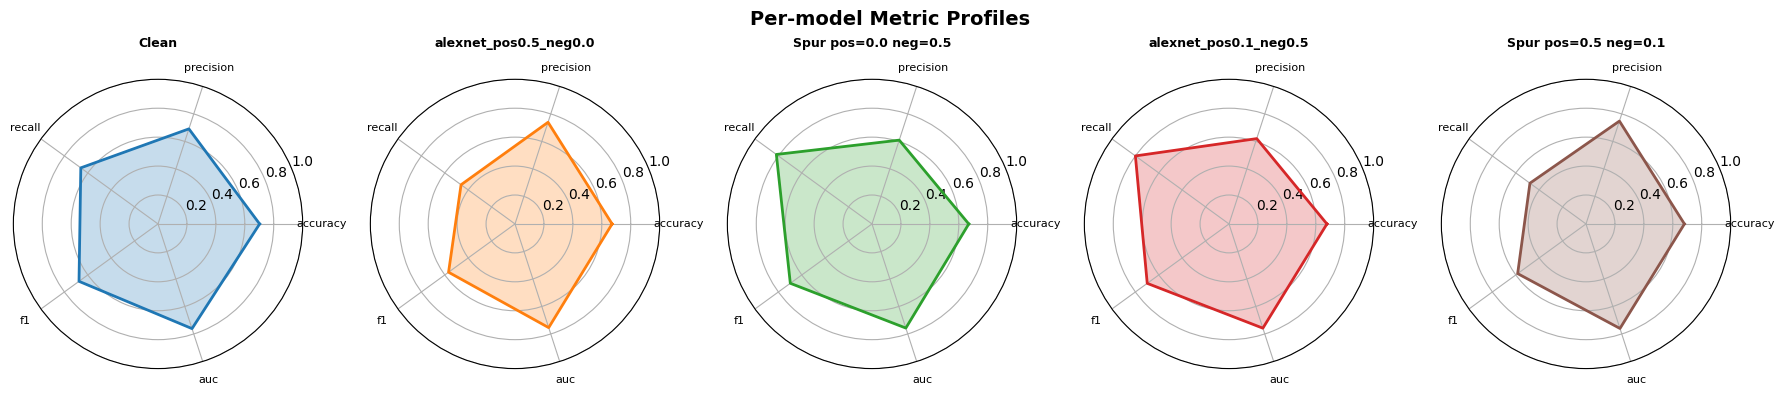

In [8]:
radar_metrics = ["accuracy", "precision", "recall", "f1", "auc"]  # exclude loss for radar
N = len(radar_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, len(models), figsize=(18, 4), subplot_kw=dict(polar=True))

for ax, model, label, color in zip(axes, models, labels, colors):
    values = [data[model][m] for m in radar_metrics]
    values += values[:1]
    ax.plot(angles, values, color=color, linewidth=2)
    ax.fill(angles, values, color=color, alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_metrics, size=8)
    ax.set_ylim(0, 1)
    ax.set_title(label, size=9, fontweight="bold", pad=12)

fig.suptitle("Per-model Metric Profiles", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/radar_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Delta vs Clean Baseline

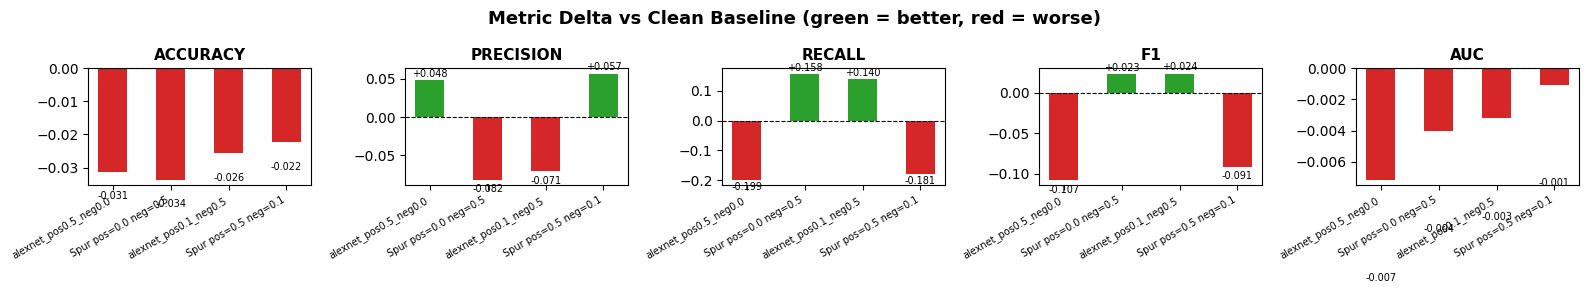

In [9]:
baseline_key = "alexnet_clean"
spurious_models = [m for m in models if m != baseline_key]
spurious_labels = [label_map.get(m, m) for m in spurious_models]
delta_metrics = ["accuracy", "precision", "recall", "f1", "auc"]

fig, axes = plt.subplots(1, len(delta_metrics), figsize=(16, 5), sharey=False)

for ax, metric in zip(axes, delta_metrics):
    deltas = [data[m][metric] - data[baseline_key][metric] for m in spurious_models]
    bar_colors = ["#d62728" if d < 0 else "#2ca02c" for d in deltas]
    x = np.arange(len(spurious_models))
    bars = ax.bar(x, deltas, color=bar_colors, width=0.5)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(metric.upper(), fontsize=11, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(spurious_labels, rotation=30, ha="right", fontsize=7)
    for bar, val in zip(bars, deltas):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + (0.002 if val >= 0 else -0.006),
                f"{val:+.3f}", ha="center", va="bottom" if val >= 0 else "top", fontsize=7)

fig.suptitle("Metric Delta vs Clean Baseline (green = better, red = worse)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/delta_vs_clean.png", dpi=150, bbox_inches="tight")
plt.show()